# Motivation

Last semester, we talked about pricing and hedging European options. Today, we want to continue discussing the pricing and hedging of Forward and American options under a stochastic process.

* Forward : A contract to deliver or receive an asset on a future date for a fixed cash amount.

$$
\text{Forward payoff function} : f(X_t) = X_t - K \text{, where K is the strike price.}
$$

* American option : An option that can be exercised on any day before expiration.

$$
\text{American option payoff function} : f(X_t) = max(X_{t}-X_{0},0)
$$

Both Forward contracts and American options can be exercised before expiration, raising questions about how to determine their price and how they can be used for hedging.



# Background

## Definition

* Pricing : Determination of fair value of an asset or derivative
* Hedging : Protect against market movements with "opposite" trades
* Replication : Clone payoff of a derivative with trades in other assets

## Claim

* **Optimal Exercise of American Options** in an idealized setting involves stochastic control, treating the decision to exercise as an optimal stopping problem.
* **Optimal Hedging of Derivative Portfolios** in a real-world setting also uses stochastic control techniques to manage risk and returns effectively.

Expressing these problems as Markov Decision Processes (MDP) Control brings Approximate Dynamic Programming (ADP) and Reinforcement Learning (RL) into play. Specifically, the Optimal Exercise of American Options can be seen as an Optimal Stopping problem.

# Optimal Stopping problem as Markov Decision Processes

## Stopping time

A stopping time $\tau$ is defined by a “stopping policy” to decide whether to continue or stop a process based on the current position and past events.

The stopping time $\tau$ represents a "random time" (a random variable) such that the probability $\Pr[\tau \leq t]$ is included in the $\sigma$-algebra $\mathbb{F}_t$ for all $t$. This means that the decision whether $\tau \leq t$ relies solely on information available up to time $t$.

For instance, consider the hitting time of a Borel set $A$ for a process $X_{t}$, which is defined as the first time $X_{t}$ enters the set $A$. Formally, this is expressed as $T_{X,A} = \min \{t \in \mathbb{R} | X_{t} \in A \}$.

## Optimal Stopping problem

The Optimal Stopping problem for a stochastic process $X_t$ is defined as:

$$
W(x) = \max_{\tau} \mathbb{E} [H(X_{t}) | X_{0} = x ]
$$

where $\tau$ represents a set of stopping times for $X_t$, $W(\cdot)$ is the value function, and $H$ is the reward function.

In scenarios where multiple stopping times can maximize $\mathbb{E}[H(X_{t})]$, we define the optimal stopping time as the smallest one among those achieving the maximum value.

---

**Formulating Stopping Time Problems as Markov Decision Processes (MDP):**

* **State:** The current state is represented by $X_t$.
* **Action:** The action is a binary choice: to stop or to continue.
* **Reward:** The reward is 0 for all actions, except when stopping, at which point it corresponds to $H(X_{\tau})$.
* **State Transitions:** These are governed by the stochastic process $X_t$.
* **Bellman Optimality Equation for Discrete Time Steps:**

$$
V^{*}(X_{t}) = max(H(X_{t}),\mathbb{E}[V^{*}(X_{t+1})|X_{t}])
$$

For a finite number of time steps, a simple backward induction algorithm can be employed, starting from the final time step and working backward to time step 0.

## Solve American Option Pricing

American Option Pricing can be viewed as an Optimal Stopping problem and, therefore, formulated as a Markov Decision Process (MDP). This formulation allows us to apply Dynamic Programming or Reinforcement Learning (RL) algorithms for its resolution.

When the payoff is not path-dependent and the state dimension is manageable, backward induction can be effectively performed on a binomial/trinomial tree or grid. For more complex scenarios, the standard approach is the Longstaff-Schwartz algorithm.

The Longstaff-Schwartz algorithm integrates three key concepts:

* **Valuation via Monte-Carlo Simulation:** It simulates a multitude of paths to estimate the option's value.
* **Function Approximation for Continuation Value:** For states where the option is in the money, it approximates the value of continuing to hold the option rather than exercising it early.
* **Backward-Recursive Early Exercise Decision:** It determines the optimal points in time to exercise the option early, working backward from expiration.

Reinforcement Learning (RL) presents a compelling alternative to the Longstaff-Schwartz algorithm, offering potential advantages in adaptability and efficiency.


# Pricing and Hedging

## Pricing and Hedging in a complete Market

Classical Pricing and Hedging Theory is founded on several critical assumptions:

* **Arbitrage-Free Market:** A condition where it's impossible to generate profits out of nothing due to perfectly efficient market operations.
* **Replication:** The process by which the payoff of a derivative can be duplicated by assembling (and periodically rebalancing) a portfolio of the underlying securities.
* **Complete Market:** A market scenario where the payoffs of all derivatives can be replicated, ensuring that every financial instrument can be priced.
* **Risk-Neutral Measure:** An adjusted probability measure that simplifies the pricing of derivatives by assuming investors are indifferent to risk.
* **Frictionless Market:** Idealized trading conditions that allow for continuous trading in any volume without incurring transaction costs.

Given that the market is both arbitrage-free and complete, a replication strategy can be employed to address Pricing and Hedging problems. This concept underpins the well-known Black-Scholes formulas.

However, in the real world, various frictions exist, leading to market incompleteness. Consequently, it's often impossible to exactly replicate derivatives, challenging the application of classical theories under these conditions.

## Pricing and Hedging in an incomplete Market

In an incomplete market, the presence of multiple risk-neutral measures leads to multiple derivative prices, each consistent with the principle of no-arbitrage.

This diversity poses a challenge for pricing and hedging. To navigate this, the approach shifts towards Portfolio Optimization, where a trader aims to maximize the "risk-adjusted return" of the derivative and its hedges.

This involves balancing a specified preference for trading risk against return, effectively determining a Utility function.

This scenario is akin to addressing the Portfolio Optimization problem previously discussed. Similarly, this can be framed as a stochastic control (MDP) problem, where the decision at each timestep involves trading in the hedges.

So we solve the MDP with Deep Reinforcement Learning (DRL).

# Setup

* Assume time is in discrete (finite) steps $ t = 0, 1, . . . , T $
* Assume we have a position (portfolio) $D$ in m derivatives
* Assume each of these $m$ derivatives expires in time $\leq T$
* Assume we have $n$ underlying market securities as potential hedges
* Assume there are a fixed number $n$ of risky assets and
a single riskless asset.
* Hedge positions (units held) at time $t$ denoted $\alpha_{t} \in \mathbb{R}^{n}$
* Cashflows per unit of hedges held at time $t$ denoted $Y_{t} \in \mathbb{R}^{n}$
* Prices per unit of hedges at time $t$ denoted $P_{t} \in \mathbb{R}^{n}$
* Trading account position at time $t$ is denoted as $\beta_{t} \in \mathbb{R}$
* Denote state space at time $t$ as $S_{t}$, state at time $t$ as $s_t \in S_{t}$
* Among other things, st contains $\alpha_{t}, P_{t}, \beta_{t}, D$
* $s_{t}$ will include any market information relevant to trading actions
* Denote action space at time $t$ as $A_{t}$, action at time $t$ as $a_{t} \in A_{t}$
* $a_{t}$ represents units of hedges traded (positive for buy, negative for sell)
* Trading restrictions (eg: no short-selling) define $A_{t}$ as a function of $s_{t}$

Assuming time is divided into discrete (finite) steps $t = 0, 1, ..., T$, consider a position (portfolio) $D$ composed of $m$ derivatives, each expiring at or before time $T$.

There are $n$ underlying market securities available as potential hedges. The hedge positions, or units held at time $t$, are denoted by $\alpha_{t} \in \mathbb{R}^{n}$. Cashflows per unit of hedges held at time $t$ are represented by $Y_{t} \in \mathbb{R}^{n}$, and prices per unit of hedges at time $t$ are denoted by $P_{t} \in \mathbb{R}^{n}$. The trading account position at time $t$ is expressed as $\beta_{t} \in \mathbb{R}$.

The state space at time $t$ is denoted as $S_{t}$, with the state at time $t$ being $s_t \in S_{t}$. This state includes, among other factors, $\alpha_{t}, P_{t}, \beta_{t},$ and $D$, and encompasses any market information relevant to trading decisions. The action space at time $t$ is represented as $A_{t}$, with the action at time $t$ being $a_{t} \in A_{t}$, indicating the units of hedges traded (positive for buying, negative for selling). Trading restrictions, such as no short-selling, define $A_{t}$ as a function of $s_{t}$.

## Solve problem

Given the state $s_t = (\alpha_t, P_t, \beta_t, D)$ and performing the action $a_t$, the change in the account position is $-a^T_t \cdot P_t$. Including trading transaction costs, for example, $-\gamma \cdot |a^T_t| \cdot P_t$ for some $\gamma > 0$, we update $\alpha_t$ as follows: $\alpha_{t+1} = \alpha_t + a_t$. Consequently, the cashflows become $X_{t+1} + \alpha^T_{t+1} \cdot Y_{t+1}$. The trading account position $\beta_t$ is updated to

$$
\beta_{t+1} = \beta_t - a^T_t \cdot P_t - \gamma \cdot |a^T_t \cdot P_t| + X_{t+1} + \alpha^T_{t+1} \cdot Y_{t+1}
$$

The reward $r_t$ is set to $0$ for all $t = 0, ..., T - 1$, and for $r_T = U(\beta_{T+1})$, where $U$ is an appropriate concave utility function reflective of risk aversion.

The optimal value function at time $t$, denoted $V^*_t: S_t \rightarrow \mathbb{R}$, allows us to define the indifferent price $x$ of new derivatives $D'$ by ensuring that

$$
V^*_0((\alpha_0, P_0, \beta_0 - x, D \cup D')) = V^0((\alpha_0, P_0, \beta_0, D)).
$$

This equation seeks to balance the initial value function with and without the addition of the new derivative $D'$, accounting for the cost $x$.

In [ ]:
!pip install rl

ERROR: Could not find a version that satisfies the requirement rl.gen_utils (from versions: none)
ERROR: No matching distribution found for rl.gen_utils


In [ ]:
!cd rl-book

/bin/bash: line 1: cd: rl-book: No such file or directory


In [ ]:
!pip install -r requirements.txt

ERROR: Could not open requirements file: [Errno 2] No such file or directory: 'requirements.txt'


In [ ]:
from rl.distribution import Constant, Categorical
from rl.finite_horizon import optimal_vf_and_policy
from rl.dynamic_programming import V
from rl.policy import FiniteDeterministicPolicy

@dataclass(frozen=True)
class OptimalExerciseBinTree:
    spot_price: float
    payoff: Callable[[float, float], float]
    expiry: float
    rate: float
    vol: float
    num_steps: int
    def dt(self) -> float:
        return self.expiry / self.num_steps
    def state_price(self, i: int, j: int) -> float:
        return self.spot_price * np.exp((2 * j - i) *self.vol * np.sqrt(self.dt()))
    def get_opt_vf_and_policy(self) -> \
            Iterator[Tuple[V[int],FiniteDeterministicPolicy[int, bool]]]:
        dt: float = self.dt()
        up_factor: float = np.exp(self.vol * np.sqrt(dt))
        up_prob: float = (np.exp(self.rate * dt) * up_factor - 1) / \
            (up_factor * up_factor - 1)
        return optimal_vf_and_policy(
            steps=[
                {NonTerminal(j): {
                    True: Constant(
                        (
                            Terminal(-1),
                            self.payoff(i * dt,self.state_price(i, j))
                        )
                    ),
                    False: Categorical(
                        {
                            (NonTerminal(j + 1), 0.): up_prob,
                            (NonTerminal(j), 0.): 1 - up_prob
                        }
                    )
                } for j in range(i + 1)}
                for i in range(self.num_steps + 1)
            ],
            gamma=np.exp(-self.rate * dt)
        )

    def option_exercise_boundary(
        self,
        policy_seq: Sequence[FiniteDeterministicPolicy[int,bool]],
        is_call: bool
    ) -> Sequence[Tuple[float, float]]:
        dt: float = self.dt()
        ex_boundary: List[Tuple[float, float]] = []
        for i in range(self.num_steps + 1):
            ex_points = [j for j in range(i + 1)
                        if policy_seq[i].action_for[j] and
                        self.payoff(i * dt,self.state_price(i, j)) > 0]
            if len(ex_points) > 0:
                boundary_pt = min(ex_points) if is_call else max(ex_points)
                ex_boundary.append(
                    (i * dt, opt_ex_bin_tree.state_price(i, boundary_pt))
                )
        return ex_boundary

from scipy.stats import norm
    def european_price(self, is_call: bool, strike: float) -> float:
        sigma_sqrt: float = self.vol * np.sqrt(self.expiry)
        d1: float = (np.log(self.spot_price / strike) +
(self.rate + self.vol ** 2 / 2.) * self.expiry) \
/ sigma_sqrt
        d2: float = d1 - sigma_sqrt
        if is_call:
            ret = self.spot_price * norm.cdf(d1) - \
                strike * np.exp(-self.rate * self.expiry) * norm.cdf(d2)
        else:
            ret = strike * np.exp(-self.rate * self.expiry) * norm.cdf(-d2) - \
                self.spot_price * norm.cdf(-d1)
        return ret



IndentationError: unexpected indent (<ipython-input-1-a45f02dd98f7>, line 64)

In [ ]:
from rl.gen_utils.plot_funcs import plot_list_of_curves

spot_price_val: float = 100.0
strike: float = 100.0
is_call: bool = False
expiry_val: float = 1.0
rate_val: float = 0.05
vol_val: float = 0.25
num_steps_val: int = 300
if is_call:
    opt_payoff = lambda _, x: max(x - strike, 0)
else:
    opt_payoff = lambda _, x: max(strike - x, 0)
opt_ex_bin_tree: OptimalExerciseBinTree = OptimalExerciseBinTree(
    spot_price=spot_price_val,
    payoff=opt_payoff,
    expiry=expiry_val,
    rate=rate_val,
    vol=vol_val,
    num_steps=num_steps_val
)
vf_seq, policy_seq = zip(*opt_ex_bin_tree.get_opt_vf_and_policy())
ex_boundary: Sequence[Tuple[float, float]] = \
    opt_ex_bin_tree.option_exercise_boundary(policy_seq, is_call)
time_pts, ex_bound_pts = zip(*ex_boundary)
label = ("Call" if is_call else "Put") + " Option Exercise Boundary "
plot_list_of_curves(
    list_of_x_vals=[time_pts],
    list_of_y_vals=[ex_bound_pts],
    list_of_colors=["b"],
    list_of_curve_labels=[label],
    x_label="Time",
    y_label="Underlying Price",
    title=label
)
european: float = opt_ex_bin_tree.european_price(is_call, strike)
print(f"European Price = {european:.3f}")
am_price: float = vf_seq[0][NonTerminal(0)]
print(f"American Price = {am_price:.3f}")

ModuleNotFoundError: No module named 'rl'

In [ ]:
!pip install rl

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 443.1/443.1 kB 7.1 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for rl: filename=rl-3.1-cp310-cp310-linux_x86_64.whl size=195554 sha256=85a7ca4b4581365c6f9ec1ab732fabd6d1298b026dcc2dd7c4066f09736ae978
  Stored in directory: /root/.cache/pip/wheels/65/48/60/7aafc3b415ac465a5103d7a250d7460343df02a615504a8e5f
Successfully built rl


Complete Market Price = 11.429
Complete Market Alpha = 0.400
Complete Market Beta = -51.429
--- Risk Aversion Param = 0.30 ---
MEU for Zero Alpha = 0.027
MEU for Zero Beta = -2.667
MEU for Zero Max Val = 0.066
{'price': 23.278610669792887, 'alpha': 0.5266666666733752, 'beta': -75.9452773371304}
--- Risk Aversion Param = 0.60 ---
MEU for Zero Alpha = 0.013
MEU for Zero Beta = -1.333
MEU for Zero Max Val = 0.033
{'price': 12.668984429183428, 'alpha': 0.5133333334356953, 'beta': -64.00231777275296}
--- Risk Aversion Param = 0.90 ---
MEU for Zero Alpha = 0.009
MEU for Zero Beta = -0.889
MEU for Zero Max Val = 0.022
{'price': 8.865213622191634, 'alpha': 0.5088888965132247, 'beta': -59.7541032735141}


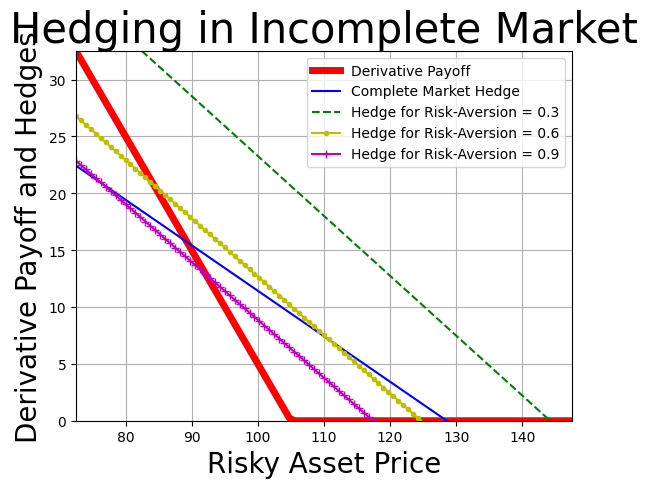

In [ ]:
from dataclasses import dataclass
from typing import Callable, Mapping
from scipy.optimize import minimize_scalar, root_scalar
from scipy.integrate import quad
import numpy as np


@dataclass(frozen=True)
class MaxExpUtility:
    """
    The goal is to compute the price and hedges for a derivative
    for a single risky asset in a single time-period setting. We
    assume that the risky asset takes on a continuum of values
    at t=1 (hedge of risky and riskless assets established
    at t = 0). This corresponds to an incomplete market scenario
    and so, there is no unique price. We determine pricing
    and hedging using the Maximum Expected Utility method and
    assume that the Utility function is CARA U(x) = (1-e^{-ax})/a,
    where a is the risk-aversion parameter. We assume the risky asset
    follows a normal distribution at t=1.
    """
    risky_spot: float  # risky asset price at t=0
    riskless_rate: float  # riskless asset price grows from 1 to 1+r
    risky_mean: float  # mean of risky asset price at t=1
    risky_stdev: float  # std dev of risky asset price at t=1
    payoff_func: Callable[[float], float]  # derivative payoff at t=1

    def complete_mkt_price_and_hedges(self) -> Mapping[str, float]:
        """
        This computes the price and hedges assuming a complete
        market, which means the risky asset takes on two values
        at t=1. 1) mean + stdev 2) mean - stdev, with equal
        probabilities. This situation can be perfectly hedged
        with a risky and a riskless asset. The following
        code provides the solution for the 2 equations and 2
        variables system
        alpha is the hedge in the risky asset units and beta
        is the hedge in the riskless asset units
        """
        x = self.risky_mean + self.risky_stdev
        z = self.risky_mean - self.risky_stdev
        v1 = self.payoff_func(x)
        v2 = self.payoff_func(z)
        alpha = (v1 - v2) / (z - x)
        beta = - 1 / (1 + self.riskless_rate) * (v1 + alpha * x)
        price = - (beta + alpha * self.risky_spot)
        return {"price": price, "alpha": alpha, "beta": beta}

    def max_exp_util_for_zero(
        self,
        c: float,
        risk_aversion_param: float
    ) -> Mapping[str, float]:
        """
        This implements the closed-form solution when the derivative
        payoff is uniformly 0
        The input c refers to the cash one pays at t=0
        This means the net position of risky asset together with riskless
        asset is -c, i.e., alpha * risky_spot + beta = -c
        """
        ra = risk_aversion_param
        er = 1 + self.riskless_rate
        mu = self.risky_mean
        sigma = self.risky_stdev
        s0 = self.risky_spot
        alpha = (mu - s0 * er) / (ra * sigma * sigma)
        beta = - (c + alpha * self.risky_spot)
        max_val = (1 - np.exp(-ra * (-er * c + alpha * (mu - s0 * er))
                              + (ra * alpha * sigma) ** 2 / 2)) / ra
        return {"alpha": alpha, "beta": beta, "max_val": max_val}

    def max_exp_util(
        self,
        c: float,
        pf: Callable[[float], float],
        risk_aversion_param: float
    ) -> Mapping[str, float]:
        sigma2 = self.risky_stdev * self.risky_stdev
        mu = self.risky_mean
        s0 = self.risky_spot
        er = 1 + self.riskless_rate
        factor = 1 / np.sqrt(2 * np.pi * sigma2)

        integral_lb = self.risky_mean - self.risky_stdev * 6
        integral_ub = self.risky_mean + self.risky_stdev * 6

        def eval_expectation(alpha: float, c=c) -> float:

            def integrand(rand: float, alpha=alpha, c=c) -> float:
                payoff = pf(rand) - er * c\
                         + alpha * (rand - er * s0)
                exponent = -(0.5 * (rand - mu) * (rand - mu) / sigma2
                             + risk_aversion_param * payoff)
                return (1 - factor * np.exp(exponent)) / risk_aversion_param

            return -quad(integrand, integral_lb, integral_ub)[0]

        res = minimize_scalar(eval_expectation)
        alpha_star = res["x"]
        max_val = - res["fun"]
        beta_star = - (c + alpha_star * s0)
        return {"alpha": alpha_star, "beta": beta_star, "max_val": max_val}

    def max_exp_util_price_and_hedge(
        self,
        risk_aversion_param: float
    ) -> Mapping[str, float]:
        meu_for_zero = self.max_exp_util_for_zero(
            0.,
            risk_aversion_param
        )["max_val"]

        def prep_func(pr: float) -> float:
            return self.max_exp_util(
                pr,
                self.payoff_func,
                risk_aversion_param
            )["max_val"] - meu_for_zero

        lb = self.risky_mean - self.risky_stdev * 10
        ub = self.risky_mean + self.risky_stdev * 10
        payoff_vals = [self.payoff_func(x) for x in np.linspace(lb, ub, 1001)]
        lb_payoff = min(payoff_vals)
        ub_payoff = max(payoff_vals)

        opt_price = root_scalar(
            prep_func,
            bracket=[lb_payoff, ub_payoff],
            method="brentq"
        ).root

        hedges = self.max_exp_util(
            opt_price,
            self.payoff_func,
            risk_aversion_param
        )
        alpha = hedges["alpha"]
        beta = hedges["beta"]
        return {"price": opt_price, "alpha": alpha, "beta": beta}


if __name__ == '__main__':
    import matplotlib.pyplot as plt

    risky_spot_val: float = 100.0
    riskless_rate_val: float = 0.05
    risky_mean_val: float = 110.0
    risky_stdev_val: float = 25.0
    payoff_function: Callable[[float], float] = lambda x: - min(x - 105.0, 0)

    b1 = riskless_rate_val >= 0.
    b2 = risky_stdev_val > 0.
    x = risky_spot_val * (1 + riskless_rate_val)
    b3 = risky_mean_val > x > risky_mean_val - risky_stdev_val
    assert all([b1, b2, b3]), "Bad Inputs"

    meu: MaxExpUtility = MaxExpUtility(
        risky_spot=risky_spot_val,
        riskless_rate=riskless_rate_val,
        risky_mean=risky_mean_val,
        risky_stdev=risky_stdev_val,
        payoff_func=payoff_function
    )

    plt.xlabel("Risky Asset Price", size=20)
    plt.ylabel("Derivative Payoff and Hedges", size=20)
    plt.title("Hedging in Incomplete Market", size=30)
    lb = meu.risky_mean - meu.risky_stdev * 1.5
    ub = meu.risky_mean + meu.risky_stdev * 1.5
    x_plot_pts = np.linspace(lb, ub, 101)
    payoff_plot_pts = np.array([meu.payoff_func(x) for x in x_plot_pts])
    plt.plot(
        x_plot_pts,
        payoff_plot_pts,
        "r",
        linewidth=5,
        label="Derivative Payoff"
    )
    cm_ph = meu.complete_mkt_price_and_hedges()
    cm_plot_pts = - (cm_ph["beta"] + cm_ph["alpha"] * x_plot_pts)
    plt.plot(
        x_plot_pts,
        cm_plot_pts,
        "b",
        label="Complete Market Hedge"
    )
    print("Complete Market Price = %.3f" % cm_ph["price"])
    print("Complete Market Alpha = %.3f" % cm_ph["alpha"])
    print("Complete Market Beta = %.3f" % cm_ph["beta"])
    for risk_aversion_param, color in [(0.3, "g--"), (0.6, "y.-"), (0.9, "m+-")]:
        print("--- Risk Aversion Param = %.2f ---" % risk_aversion_param)
        meu_for_zero = meu.max_exp_util_for_zero(0., risk_aversion_param)
        print("MEU for Zero Alpha = %.3f" % meu_for_zero["alpha"])
        print("MEU for Zero Beta = %.3f" % meu_for_zero["beta"])
        print("MEU for Zero Max Val = %.3f" % meu_for_zero["max_val"])
        res2 = meu.max_exp_util_price_and_hedge(risk_aversion_param)
        print(res2)
        im_plot_pts = - (res2["beta"] + res2["alpha"] * x_plot_pts)
        plt.plot(
            x_plot_pts,
            im_plot_pts,
            color,
            label="Hedge for Risk-Aversion = %.1f" % risk_aversion_param
        )

    plt.xlim(lb, ub)
    plt.ylim(min(payoff_plot_pts), max(payoff_plot_pts))
    plt.grid(True)
    plt.legend()
    plt.show()

In [ ]:
from dataclasses import dataclass
from typing import Callable, Sequence, Tuple, Iterator, List
import numpy as np
from scipy.stats import norm
from rl.distribution import SampledDistribution
from rl.markov_decision_process import MarkovDecisionProcess, \
    NonTerminal, State, Terminal
from rl.policy import DeterministicPolicy
from rl.function_approx import FunctionApprox, LinearFunctionApprox
from rl.approximate_dynamic_programming import back_opt_vf_and_policy
from numpy.polynomial.laguerre import lagval


@dataclass(frozen=True)
class OptimalExerciseBI:
    '''Optimal Exercise with Backward Induction when the underlying
    price follows a lognormal process'''

    spot_price: float
    payoff: Callable[[float], float]
    expiry: float
    rate: float
    vol: float
    num_steps: int
    spot_price_frac: float

    def european_put_price(self, strike: float) -> float:
        sigma_sqrt: float = self.vol * np.sqrt(self.expiry)
        d1: float = (np.log(self.spot_price / strike) +
                     (self.rate + self.vol ** 2 / 2.) * self.expiry) \
            / sigma_sqrt
        d2: float = d1 - sigma_sqrt
        return strike * np.exp(-self.rate * self.expiry) * norm.cdf(-d2) \
            - self.spot_price * norm.cdf(-d1)

    def get_mdp(self, t: int) -> MarkovDecisionProcess[float, bool]:
        dt: float = self.expiry / self.num_steps
        exer_payoff: Callable[[float], float] = self.payoff
        r: float = self.rate
        s: float = self.vol

        class OptExerciseBIMDP(MarkovDecisionProcess[float, bool]):

            def step(
                self,
                price: NonTerminal[float],
                exer: bool
            ) -> SampledDistribution[Tuple[State[float], float]]:

                def sr_sampler_func(
                    price=price,
                    exer=exer
                ) -> Tuple[State[float], float]:
                    if exer:
                        return Terminal(0.), exer_payoff(price.state)
                    else:
                        next_price: float = np.exp(np.random.normal(
                            np.log(price.state) + (r - s * s / 2) * dt,
                            s * np.sqrt(dt)
                        ))
                        return NonTerminal(next_price), 0.

                return SampledDistribution(
                    sampler=sr_sampler_func,
                    expectation_samples=200
                )

            def actions(self, price: NonTerminal[float]) -> Sequence[bool]:
                return [True, False]

        return OptExerciseBIMDP()

    def get_states_distribution(
        self,
        t: int
    ) -> SampledDistribution[NonTerminal[float]]:
        spot_mean2: float = self.spot_price * self.spot_price
        spot_var: float = spot_mean2 * \
            self.spot_price_frac * self.spot_price_frac
        log_mean: float = np.log(spot_mean2 / np.sqrt(spot_var + spot_mean2))
        log_stdev: float = np.sqrt(np.log(spot_var / spot_mean2 + 1))

        time: float = t * self.expiry / self.num_steps

        def states_sampler_func() -> NonTerminal[float]:
            start: float = np.random.lognormal(log_mean, log_stdev)
            price = np.exp(np.random.normal(
                np.log(start) + (self.rate - self.vol * self.vol / 2) * time,
                self.vol * np.sqrt(time)
            ))
            return NonTerminal(price)

        return SampledDistribution(states_sampler_func)

    def get_vf_func_approx(
        self,
        t: int,
        features: Sequence[Callable[[NonTerminal[float]], float]],
        reg_coeff: float
    ) -> LinearFunctionApprox[NonTerminal[float]]:
        return LinearFunctionApprox.create(
            feature_functions=features,
            regularization_coeff=reg_coeff,
            direct_solve=True
        )

    def backward_induction_vf_and_pi(
        self,
        features: Sequence[Callable[[NonTerminal[float]], float]],
        reg_coeff: float
    ) -> Iterator[
        Tuple[FunctionApprox[NonTerminal[float]],
              DeterministicPolicy[float, bool]]
    ]:

        mdp_f0_mu_triples: Sequence[Tuple[
            MarkovDecisionProcess[float, bool],
            FunctionApprox[NonTerminal[float]],
            SampledDistribution[NonTerminal[float]]
        ]] = [(
            self.get_mdp(t=i),
            self.get_vf_func_approx(
                t=i,
                features=features,
                reg_coeff=reg_coeff
            ),
            self.get_states_distribution(t=i)
        ) for i in range(self.num_steps + 1)]

        num_state_samples: int = 1000

        return back_opt_vf_and_policy(
            mdp_f0_mu_triples=mdp_f0_mu_triples,
            γ=np.exp(-self.rate * self.expiry / self.num_steps),
            num_state_samples=num_state_samples,
            error_tolerance=1e-8
        )

    def optimal_value_curve(
        self,
        func: FunctionApprox[NonTerminal[float]],
        prices: Sequence[float]
    ) -> np.ndarray:
        return func.evaluate([NonTerminal(p) for p in prices])

    def exercise_curve(
        self,
        prices: Sequence[float]
    ) -> np.ndarray:
        return np.array([self.payoff(p) for p in prices])

    def put_option_exercise_boundary(
        self,
        opt_vfs: Sequence[FunctionApprox[NonTerminal[float]]],
        strike: float
    ) -> Sequence[float]:
        ret: List[float] = []
        prices: np.ndarray = np.arange(0., strike + 0.1, 0.1)
        for vf in opt_vfs[:-1]:
            cp: np.ndarray = self.optimal_value_curve(
                func=vf,
                prices=prices
            )
            ep: np.ndarray = self.exercise_curve(prices=prices)
            ll: Sequence[float] = [p for p, c, e in zip(prices, cp, ep)
                                   if e > c]
            ret.append(max(ll) if len(ll) > 0 else 0.)
        final: Sequence[Tuple[float, float]] = \
            [(p, self.payoff(p)) for p in prices]
        ret.append(max(p for p, e in final if e > 0))
        return ret


if __name__ == '__main__':
    import matplotlib.pyplot as plt

    spot_price_val: float = 100.0
    strike: float = 100.0
    expiry_val: float = 1.0
    rate_val: float = 0.05
    vol_val: float = 0.25
    num_steps_val: int = 10
    spot_price_frac_val: float = 0.02

    opt_ex_bi: OptimalExerciseBI = OptimalExerciseBI(
        spot_price=spot_price_val,
        payoff=lambda x: max(strike - x, 0.),
        expiry=expiry_val,
        rate=rate_val,
        vol=vol_val,
        num_steps=num_steps_val,
        spot_price_frac=spot_price_frac_val
    )

    num_laguerre: int = 4
    reglr_coeff: float = 0.001

    ident: np.ndarray = np.eye(num_laguerre)
    ffs: List[Callable[[NonTerminal[float]], float]] = [lambda _: 1.]
    ffs += [(lambda s, i=i: np.log(1 + np.exp(-s.state / (2 * strike))) *
            lagval(s.state / strike, ident[i]))
            for i in range(num_laguerre)]
    it_vf = opt_ex_bi.backward_induction_vf_and_pi(
        features=ffs,
        reg_coeff=reglr_coeff
    )

    prices: np.ndarray = np.arange(120.0)

    print("Backward Induction: VF And Policy")
    print("---------------------------------")
    print()

    all_funcs: List[FunctionApprox[NonTerminal[float]]] = []
    for t, (v, p) in enumerate(it_vf):
        print(f"Time {t:d}")
        print()

        if t == 0 or t == int(num_steps_val / 2) or t == num_steps_val - 1:
            exer_curve: np.ndarray = opt_ex_bi.exercise_curve(
                prices=prices
            )
            opt_val_curve: np.ndarray = opt_ex_bi.optimal_value_curve(
                func=v,
                prices=prices
            )
            plt.plot(
                prices,
                opt_val_curve,
                "r",
                prices,
                exer_curve,
                "b"
            )
            time: float = t * expiry_val / num_steps_val
            plt.title(f"OptVal and Exercise Curves for Time = {time:.3f}")
            plt.show()

        all_funcs.append(v)

        opt_alloc: float = p.action_for(spot_price_val)
        val: float = v(NonTerminal(spot_price_val))
        print(f"Opt Action = {opt_alloc}, Opt Val = {val:.3f}")
        print()

    ex_bound: Sequence[float] = opt_ex_bi.put_option_exercise_boundary(
        all_funcs,
        strike
    )
    plt.plot(range(num_steps_val + 1), ex_bound)
    plt.title("Exercise Boundary")
    plt.show()

    print("European Put Price")
    print("------------------")
    print()
    print(opt_ex_bi.european_put_price(strike=strike))

ModuleNotFoundError: No module named 'rl'

In [ ]:
from dataclasses import dataclass
from typing import Callable, Tuple, Iterator, Sequence, List
import numpy as np
from rl.dynamic_programming import V
from scipy.stats import norm
from rl.markov_decision_process import Terminal, NonTerminal
from rl.policy import FiniteDeterministicPolicy
from rl.distribution import Constant, Categorical
from rl.finite_horizon import optimal_vf_and_policy


@dataclass(frozen=True)
class OptimalExerciseBinTree:

    spot_price: float
    payoff: Callable[[float, float], float]
    expiry: float
    rate: float
    vol: float
    num_steps: int

    def european_price(self, is_call: bool, strike: float) -> float:
        sigma_sqrt: float = self.vol * np.sqrt(self.expiry)
        d1: float = (np.log(self.spot_price / strike) +
                     (self.rate + self.vol ** 2 / 2.) * self.expiry) \
            / sigma_sqrt
        d2: float = d1 - sigma_sqrt
        if is_call:
            ret = self.spot_price * norm.cdf(d1) - \
                strike * np.exp(-self.rate * self.expiry) * norm.cdf(d2)
        else:
            ret = strike * np.exp(-self.rate * self.expiry) * norm.cdf(-d2) - \
                self.spot_price * norm.cdf(-d1)
        return ret

    def dt(self) -> float:
        return self.expiry / self.num_steps

    def state_price(self, i: int, j: int) -> float:
        return self.spot_price * np.exp((2 * j - i) * self.vol *
                                        np.sqrt(self.dt()))

    def get_opt_vf_and_policy(self) -> \
            Iterator[Tuple[V[int], FiniteDeterministicPolicy[int, bool]]]:
        dt: float = self.dt()
        up_factor: float = np.exp(self.vol * np.sqrt(dt))
        up_prob: float = (np.exp(self.rate * dt) * up_factor - 1) / \
            (up_factor * up_factor - 1)
        return optimal_vf_and_policy(
            steps=[
                {NonTerminal(j): {
                    True: Constant(
                        (
                            Terminal(-1),
                            self.payoff(i * dt, self.state_price(i, j))
                        )
                    ),
                    False: Categorical(
                        {
                            (NonTerminal(j + 1), 0.): up_prob,
                            (NonTerminal(j), 0.): 1 - up_prob
                        }
                    )
                } for j in range(i + 1)}
                for i in range(self.num_steps + 1)
            ],
            gamma=np.exp(-self.rate * dt)
        )

    def option_exercise_boundary(
        self,
        policy_seq: Sequence[FiniteDeterministicPolicy[int, bool]],
        is_call: bool
    ) -> Sequence[Tuple[float, float]]:
        dt: float = self.dt()
        ex_boundary: List[Tuple[float, float]] = []
        for i in range(self.num_steps + 1):
            ex_points = [j for j in range(i + 1)
                         if policy_seq[i].action_for[j] and
                         self.payoff(i * dt, self.state_price(i, j)) > 0]
            if len(ex_points) > 0:
                boundary_pt = min(ex_points) if is_call else max(ex_points)
                ex_boundary.append(
                    (i * dt, self.state_price(i, boundary_pt))
                )
        return ex_boundary


if __name__ == '__main__':
    from rl.gen_utils.plot_funcs import plot_list_of_curves
    spot_price_val: float = 100.0
    strike: float = 100.0
    is_call: bool = False
    expiry_val: float = 1.0
    rate_val: float = 0.05
    vol_val: float = 0.25
    num_steps_val: int = 300

    if is_call:
        opt_payoff = lambda _, x: max(x - strike, 0)
    else:
        opt_payoff = lambda _, x: max(strike - x, 0)

    opt_ex_bin_tree: OptimalExerciseBinTree = OptimalExerciseBinTree(
        spot_price=spot_price_val,
        payoff=opt_payoff,
        expiry=expiry_val,
        rate=rate_val,
        vol=vol_val,
        num_steps=num_steps_val
    )

    vf_seq, policy_seq = zip(*opt_ex_bin_tree.get_opt_vf_and_policy())
    ex_boundary: Sequence[Tuple[float, float]] = \
        opt_ex_bin_tree.option_exercise_boundary(policy_seq, is_call)
    time_pts, ex_bound_pts = zip(*ex_boundary)
    label = ("Call" if is_call else "Put") + " Option Exercise Boundary"
    plot_list_of_curves(
        list_of_x_vals=[time_pts],
        list_of_y_vals=[ex_bound_pts],
        list_of_colors=["b"],
        list_of_curve_labels=[label],
        x_label="Time",
        y_label="Underlying Price",
        title=label
    )

    european: float = opt_ex_bin_tree.european_price(is_call, strike)
    print(f"European Price = {european:.3f}")

    am_price: float = vf_seq[0][NonTerminal(0)]
    print(f"American Price = {am_price:.3f}")

ModuleNotFoundError: No module named 'rl'

# Single-Period


Our simple setting involves discrete time

*  a single-period from $t = 0$ to $t = 1$
* Time $t = 0$ has a single state as the “Spot” state.
*  Time $t = 1$ has $n$ random outcomes formalized by the sample space $\omega = \{ \omega_{1}, . . . , \omega_{n} \}$
* The probability distribution is given by $\mu : \omega \rightarrow [0, 1]$ s.t. $\sum_{i=1}^{n} \mu(\omega_{i}) = 1$
* $m + 1$ fundamental assets $A_{0}, A_{1}, . . . , A_{m}$
where $A_{0}$ is a riskless asset which price is 1 and $A_{1}, . . . , A_{m}$ are risky assets.

We denote the Spot Price (at $t = 0$) of $A_{j}$ as $S^{(0)}_{j}$ for all $j = 0, 1, . . . , m$. We denote the Price of $A_{j}$ in $\omega_{i}$ as $S^{(i)}_{j}$ for all $j = 0, . . . , m, i = 1, . . . , n$.

Then, we have

$$
S^{(0)}_{0} = 1 \text{ and } S^{(i)}_{0} = 1 + r \text{ for all } i = 1, . . . , n
$$

where $r$ represents the constant riskless rate of growth.

Our simplified setting operates within discrete time, structured as follows:

* The timeline spans a single period from $t = 0$ to $t = 1$.
* At time $t = 0$, there exists a single "Spot" state.
* At time $t = 1$, there are $n$ random outcomes, represented by the sample space $\omega = { \omega_{1}, ..., \omega_{n} }$.
* The probability distribution over these outcomes is given by $\mu : \omega \rightarrow [0, 1]$, such that $\sum_{i=1}^{n} \mu(\omega_{i}) = 1$.
* The model includes $m + 1$ fundamental assets: $A_{0}, A_{1}, ..., A_{m}$, where:
 * $A_{0}$ is a riskless asset priced at 1.
 * $A_{1}, ..., A_{m}$ are risky assets.

The spot price (at $t = 0$) of asset $A_{j}$ is denoted as $S^{(0)}{j}$ for all $j = 0, 1, ..., m$. The price of asset $A{j}$ in outcome $\omega_{i}$ is denoted as $S^{(i)}_{j}$ for all $j = 0, ..., m, i = 1, ..., n$.

Thus, we establish:

$$
S^{(0)}_{0} = 1 \text{ and } S^{(i)}_{0} = 1 + r \text{ for all } i = 1, . . . , n
$$

where $r$ is the constant riskless rate of growth.

We define a portfolio as a vector $\theta = (\theta_{0}, \theta_{1}, . . . ,\theta_{m}) \in \mathbb{R}^{(m+1)}$, representing the number of units held in the assets $A_{j} , j = 0, 1, . . . , m$. The Spot Value (at $t = 0$) of portfolio $\theta$,denoted by $V^{(0)}_{\theta}$
, is:

$$
V^{(0)}_{\theta} = \sum^{m}_{j=0} \theta_{j} \cdot S^{(0)}_{j}
$$

The Value of portfolio $\theta$ in random outcome $\omega_{i}$ (at $t = 1$), denoted by $V^{(i)}_{\theta}$, is:

$$
V^{(i)}_{\theta} = \sum^{m}_{j=\theta} \theta_{j} \cdot S^{(i)}_{j} \text{ for all } i = 1, . . . , n
$$

## Arbitrage portfolio
Define : an arbitrage portfolio is a portfolio $\theta$ such that:

* $V^{(0)}_{\theta} \leq 0$
* $V^{(i)}_{\theta} \geq 0$ for all $i = 1, . . . , n$
* There exists an $i \in \{ 1, . . . , n \}$ such that $\mu(\omega_{i}) > 0$ and $V^{(i)}_{\theta} > 0$

## Risk-Neutral Probability Measure

Consider a Probability Distribution $\pi : \Omega \rightarrow
[0, 1]$ such that

$$
\pi(\omega_{i}) = 0 \text{ if and only if } \mu(\omega_{i}) = 0 \text{ for all } i = 1, . . . , n
$$

Then, $\pi$ is said to be a Risk-Neutral Probability Measure if:

$$
S^{(0)}_{j} = \frac{1}{1 + r} \cdot \sum^{n}_{i=1} \pi(\omega_{i}) \cdot S^{(i)}_{j} \text{ for all } j = 0, 1, . . . , m
$$

## Lemma of fundamental thearom

For any portfolio $\theta = (\theta_{0}, \theta_{1}, . . . , \theta_{m}) \in \mathbb{R}^{m+1}$ and any risk-neutral probability measure $\pi : \omega \rightarrow [0, 1]$ ,

$$
V^{(0)}_{\theta} = \frac{1}{1 + r} \cdot \sum^{n}_{i=1} \pi(\omega_{i}) \cdot V^{(i)}_{\theta}
$$

pf:
$$
V^{(0)}_{\theta} = \sum^{m}_{j=0} \theta_{j} \cdot S^{(0)}_{j} = \sum^{m}_{j=0} \theta_{j} \cdot \frac{1}{1 + r} \cdot \sum^{n}_{i=1} \pi(\omega_{i}) \cdot S^{(i)}_{j} = \frac{1}{1 + r} \cdot \sum^{n}_{i=1} \pi(\omega_{i}) \cdot \sum^{m}_{j=0} \theta_{j} \cdot S^{(i)}_{j} = \frac{1}{1 + r} \cdot \sum^{n}_{i=1} \pi(\omega_{i}) \cdot V^{(i)}_{\theta}
$$

Having this lemma ,we start with the first fundamental theorem of asset pricing under absence of arbitrage with existence of a risk-neutral probability measure.

We define a portfolio as a vector $\theta = (\theta_{0}, \theta_{1}, ..., \theta_{m}) \in \mathbb{R}^{(m+1)}$, representing the number of units held in the assets $A_j$, where $j = 0, 1, ..., m$. The Spot Value (at $t = 0$) of the portfolio $\theta$, denoted by $V^{(0)}_{\theta}$, is:

$$
V^{(0)}_{\theta} = \sum^{m}_{j=0} \theta_{j} \cdot S^{(0)}_{j}
$$

The Value of the portfolio $\theta$ in the random outcome $\omega_{i}$ (at $t = 1$), denoted by $V^{(i)}_{\theta}$, is:

$$
V^{(i)}_{\theta} = \sum^{m}_{j=\theta} \theta_{j} \cdot S^{(i)}_{j} \text{ for all } i = 1, . . . , n
$$

## Arbitrage Portfolio
An arbitrage portfolio is defined as a portfolio $\theta$ such that:

* $V^{(0)}_{\theta} \leq 0$
* $V^{(i)}_{\theta} \geq 0$ for all $i = 1, ..., n$
* There exists an $i \in { 1, ..., n }$ such that $\mu(\omega_{i}) > 0$ and $V^{(i)}_{\theta} > 0$

## Risk-Neutral Probability Measure
Consider a Probability Distribution $\pi : \Omega \rightarrow [0, 1]$ such that $\pi(\omega_{i}) = 0$ if and only if $\mu(\omega_{i}) = 0$ for all $i = 1, ..., n$. Then, $\pi$ is considered a Risk-Neutral Probability Measure if:

$$
S^{(0)}_{j} = \frac{1}{1 + r} \cdot \sum^{n}_{i=1} \pi(\omega_{i}) \cdot S^{(i)}_{j} \text{ for all } j = 0, 1, . . . , m
$$

## Lemma of the Fundamental Theorem
For any portfolio $\theta = (\theta_{0}, \theta_{1}, ..., \theta_{m}) \in \mathbb{R}^{m+1}$ and any risk-neutral probability measure $\pi : \omega \rightarrow [0, 1]$,

$$
V^{(0)}_{\theta} = \frac{1}{1 + r} \cdot \sum^{n}_{i=1} \pi(\omega_{i}) \cdot V^{(i)}_{\theta}
$$

pf:
$$
V^{(0)}_{\theta} = \sum^{m}_{j=0} \theta_{j} \cdot S^{(0)}_{j} = \sum^{m}_{j=0} \theta_{j} \cdot \frac{1}{1 + r} \cdot \sum^{n}_{i=1} \pi(\omega_{i}) \cdot S^{(i)}_{j} = \frac{1}{1 + r} \cdot \sum^{n}_{i=1} \pi(\omega_{i}) \cdot \sum^{m}_{j=0} \theta_{j} \cdot S^{(i)}_{j} = \frac{1}{1 + r} \cdot \sum^{n}_{i=1} \pi(\omega_{i}) \cdot V^{(i)}_{\theta}
$$

With this lemma in place, we can now proceed to the first fundamental theorem of asset pricing, which ties the absence of arbitrage to the existence of a risk-neutral probability measure.

To introduce this theorem, we given three definitions first.

Definition : A Derivative $D$ is specified as a vector payoff at time $t = 1$, denoted as:

$$
(V^{(1)}_{D} , V^{(2)}_{D} , . . . , V^{(n)}_{D} )
$$

where $V^{(i)}_{D}$ is the payoff of the derivative in random outcome $\omega_{i}$ for all $i = 1, . . . , n$

Definition : A Portfolio $\theta = (\theta_{0}, \theta_{1}, . . . , \theta_{m}) \in \mathbb{R}^{m+1}$ is a Replicating Portfolio for derivative $D$ if:

$$
V^{(i)}_{D} = V^{(i)}_{\theta} = \sum^{m}_{j=0} \theta_{j} \cdot S^{(i)}_{j} \text{ for all } i = 1, . . . , n
$$

The negatives of the components $(\theta_{0}, \theta_{1}, . . . , \theta_{m})$ are known as the hedges for $D$ since they can be used to offset the risk in the payoff of $D$ at $t = 1$.

Definition : An arbitrage-free market is said to be Complete if every derivative in the market has a replicating portfolio.

Theorem : (Second Fundamental Theorem of Asset Pricing (2nd FTAP)). A market is Complete if and only if there is a unique
Risk-Neutral Probability Measure.

pf: \
$(\Rightarrow)$We first prove that in an arbitrage-free market, if every derivative has a replicating portfolio, then there is a unique risk-neutral probability measure.

We define $n$ special derivatives, one for each random outcome in $\omega$ at $t = 1$. We define the time $t = 1$ payoff of Arrow-Debreu security $D_{k}$ (for each of $k = 1, . . . , n$) as follows:

$$
V^{(i)}_{D_{k}} = \mathbb{I}_{i=k} \text{ for all } i = 1, . . . , n
$$

where $\mathbb{I}$ represents the indicator function.

Since each derivative has a replicating portfolio, denote $\theta^{(k)} = (θ^{(k)}_{0}, \theta^{(k)}_{1}, . . . , \theta^{(k)}_{m} )$ as the replicating portfolio for $D_{k}$ for each $k = 1, . . . , m$. Therefore, for each $k = 1, . . . , m$ :

$$
V^{(i)}_{\theta^{(k)}} = \sum^{m}_{j=0} \theta^{(k)}_{j} \cdot S^{(i)}_{j} = V^{(i)}_{D_{k}} = \mathbb{I}_{i=k} \text{ for all } i = 1, . . . , n
$$

Using above lemma, we can write the following equation for any risk-neutral probability measure $\pi$, for each $k = 1, . . . , m$ :

$$
\sum^{m}_{j=0} \theta^{(k)}_{j} \cdot S^{(0)}_{j} = V^{(0)}_{\theta^{(k)}} = \frac{1}{1 + r} \cdot \sum^{n}_{i=1} \pi(\omega_{i}) \cdot V^{(i)}_{\theta^{(k)}} = \frac{1}{1 + r} \cdot \sum^{n}_{i=1} \pi(\omega_{i}) \cdot \mathbb{I}_{i=k}
= \frac{1}{1 + r} \cdot \pi(\omega_{k})
$$

so, we get

$$
\pi(\omega_{k}) = (1+r) \cdot \sum^{m}_{j=0} \theta^{(k)}_{j} \cdot S^{(0)}_{j} \text{ for all } k = 1, . . . , n
$$

which implies that we have a unique risk-neutral probability measure.

$(\Leftarrow)$We need to prove that if there exists a risk-neutral probability measure $\pi$ and if there exists a derivative $D$ with no replicating portfolio, then we can construct a risk-neutral probability measure different than $\pi$.

Consider the following vectors in the vector space $\mathbb{R}^{n}$

$$
v = (V^{(1)}_{D} , . . . , V^{(n)}_{D} ) \text{ and } v_{j} = (S^{(1)}_{j}, . . . , S^{(n)}_{j}) \text{ for all } j = 0, 1, . . . , m
$$

Since $D$ does not have a replicating portfolio, $v$ is not in the span of $\{v_{0}, v_{1}, . . . , v_{m}\}$,
which means $\{v_{0}, v_{1}, . . . , v_{m}\}$ do not span $\mathbb{R}^{n}$. Hence, there exists a non-zero vector
$u = (u_{1}, . . . , u_{n}) \in \mathbb{R}^{n}$ orthogonal to each of $v_{0}, v_{1}, . . . , v_{m}$, i.e.,

$$
\sum^{n}_{i=1} u_{i} \cdot S^{(i)}_{j} = 0 \text{ for all } j = 0, 1, . . . , n
$$

Note that $S^{(i)}_{0} = 1 + r$ for all $i = 1, . . . , n$ and so,

$$
\sum^{n}_{i=1} u_{i} = 0
$$

Define $\pi': \omega \rightarrow \mathbb{R}$ as follows :

$$
\pi'(\omega_{i}) = \pi(\omega_{i}) + \epsilon \cdot u_{i} \text{ for all } i = 1, . . . , n
$$

for some $\epsilon \in \mathbb{R}^{+}$

To establish $\pi'$ as a risk-neutral probability measure different than $π$, note:
* Since $\sum^{n}_{i=1} \pi(\omega_{i}) = 1 $ and since $\sum^{n}_{i=1} u_{i} = 0$ ,$\sum^{n}_{i=1} \pi'(\omega_{i}) = 1$
* Construct $\pi'(\omega_{i}) > 0$ for each $i$ where $\pi(\omega_{i}) > 0$ by making $\epsilon > 0$ sufficiently small, and set $\pi'(\omega_{i})= 0$ for each $i$ where $\pi(\omega_{i}) = 0$
* we have for each $j = 0, 1, . . . , m$ :

$$
\frac{1}{1 + r} \cdot \sum^{n}_{i=1} \pi'(\omega_{i}) \cdot S^{(i)}_{j} = \frac{1}{1 + r} \cdot \sum^{n}_{i=1} \pi(\omega_{i}) \cdot S^{(i)}_{j} + \frac{\epsilon}{1 + r} \cdot \sum^{n}_{i=1} u_{i} \cdot S^{(i)}_{j} = S^{(0)}_{j}
$$

Together, the two FTAPs classify markets into:
* Market with arbitrage $\Leftrightarrow$ No risk-neutral probability measure
* Complete (arbitrage-free) market $\Leftrightarrow$ Unique risk-neutral probability measure
* Incomplete (arbitrage-free) market $\Leftrightarrow$ Multiple risk-neutral probability measures

The next topic is derivatives pricing that is based on the concepts of replication of derivatives and risk-neutral probability measures, and so is tied to the concepts of arbitrage and completeness.

To introduce this theorem, let's begin with three definitions:

**Definition 1: Derivative $D$** is specified as a vector of payoffs at time $t = 1$, denoted as:

$$
(V^{(1)}_{D} , V^{(2)}_{D} , . . . , V^{(n)}_{D} )
$$

where $V^{(i)}{D}$ represents the payoff of the derivative in the random outcome $\omega{i}$ for all $i = 1, ..., n$.

**Definition 2: Replicating Portfolio.** A portfolio $\theta = (\theta_{0}, \theta_{1}, ..., \theta_{m}) \in \mathbb{R}^{m+1}$ is a replicating portfolio for derivative $D$ if:

$$
V^{(i)}_{D} = V^{(i)}_{\theta} = \sum^{m}_{j=0} \theta_{j} \cdot S^{(i)}_{j} \text{ for all } i = 1, . . . , n
$$

The negatives of the components $(\theta_{0}, \theta_{1}, ..., \theta_{m})$ are known as the hedges for $D$, as they can be used to offset the risk in the payoff of $D$ at $t = 1$.

**Definition 3: Complete Market.** An arbitrage-free market is said to be complete if every derivative in the market has a replicating portfolio.

**Theorem (Second Fundamental Theorem of Asset Pricing - 2nd FTAP):** A market is complete if and only if there is a unique risk-neutral probability measure.

**Proof ($\Rightarrow$):** In an arbitrage-free market, if every derivative has a replicating portfolio, then there exists a unique risk-neutral probability measure. We define $n$ special derivatives, one for each random outcome at $t = 1$. The payoff of Arrow-Debreu security $D_{k}$ at time $t = 1$ for each $k = 1, ..., n$ is:

$$
V^{(i)}_{D_{k}} = \mathbb{I}_{i=k} \text{ for all } i = 1, . . . , n
$$

where $\mathbb{I}$ is the indicator function. Let $\theta^{(k)}$ be the replicating portfolio for $D_{k}$. Thus, for each $k$:

$$
V^{(i)}_{\theta^{(k)}} = \sum^{m}_{j=0} \theta^{(k)}_{j} \cdot S^{(i)}_{j} = V^{(i)}_{D_{k}} = \mathbb{I}_{i=k} \text{ for all } i = 1, . . . , n
$$

Using above lemma, we can write the following equation for any risk-neutral probability measure $\pi$, for each $k = 1, . . . , m$ :

$$
\sum^{m}_{j=0} \theta^{(k)}_{j} \cdot S^{(0)}_{j} = V^{(0)}_{\theta^{(k)}} = \frac{1}{1 + r} \cdot \sum^{n}_{i=1} \pi(\omega_{i}) \cdot V^{(i)}_{\theta^{(k)}} = \frac{1}{1 + r} \cdot \sum^{n}_{i=1} \pi(\omega_{i}) \cdot \mathbb{I}_{i=k}
= \frac{1}{1 + r} \cdot \pi(\omega_{k})
$$

Given any risk-neutral probability measure $\pi$, for each $k = 1, ..., m$:

$$
\pi(\omega_{k}) = (1+r) \cdot \sum^{m}_{j=0} \theta^{(k)}_{j} \cdot S^{(0)}_{j} \text{ for all } k = 1, . . . , n
$$

indicating a unique risk-neutral probability measure.

**Proof ($\Leftarrow$):** If a risk-neutral probability measure $\pi$ exists and a derivative $D$ without a replicating portfolio exists, then a different risk-neutral measure than $\pi$ can be constructed.

Considering vectors $v$ and $v_{j}$ in $\mathbb{R}^{n}$, and $D$ does not have a replicating portfolio, it means that ${v_{0}, v_{1}, ..., v_{m}}$ do not span $\mathbb{R}^{n}$. Therefore, a non-zero vector $u = (u_{1}, ..., u_{n})$ orthogonal to each of $v_{0}, v_{1}, ..., v_{m}$ exists,i.e.,

$$
\sum^{n}_{i=1} u_{i} \cdot S^{(i)}_{j} = 0 \text{ for all } j = 0, 1, . . . , n
$$

Note that $S^{(i)}_{0} = 1 + r$ for all $i = 1, . . . , n$ and so,

$$
\sum^{n}_{i=1} u_{i} = 0
$$

Define $\pi': \omega \rightarrow \mathbb{R}$, where $\pi'(\omega_{i}) = \pi(\omega_{i}) + \epsilon \cdot u_{i}$ for some $\epsilon > 0$, ensuring $\pi'$ differs from $\pi$ while maintaining the risk-neutral property.

* Since $\sum^{n}_{i=1} \pi(\omega_{i}) = 1 $ and since $\sum^{n}_{i=1} u_{i} = 0$ ,$\sum^{n}_{i=1} \pi'(\omega_{i}) = 1$
* Construct $\pi'(\omega_{i}) > 0$ for each $i$ where $\pi(\omega_{i}) > 0$ by making $\epsilon > 0$ sufficiently small, and set $\pi'(\omega_{i})= 0$ for each $i$ where $\pi(\omega_{i}) = 0$
* we have for each $j = 0, 1, . . . , m$ :

$$
\frac{1}{1 + r} \cdot \sum^{n}_{i=1} \pi'(\omega_{i}) \cdot S^{(i)}_{j} = \frac{1}{1 + r} \cdot \sum^{n}_{i=1} \pi(\omega_{i}) \cdot S^{(i)}_{j} + \frac{\epsilon}{1 + r} \cdot \sum^{n}_{i=1} u_{i} \cdot S^{(i)}_{j} = S^{(0)}_{j}
$$


These fundamental theorems categorize markets into:

* Markets with arbitrage are those without a risk-neutral probability measure.
* Complete markets (arbitrage-free) have a unique risk-neutral probability measure.
* Incomplete markets (arbitrage-free) feature multiple risk-neutral probability measures.

Next, we delve into derivatives pricing, building on replication and risk-neutral measures, and tied to concepts of arbitrage and completeness.

**Theorem (First Fundamental Theorem of Asset Pricing (1st FTAP)) :** Our simple setting of discrete time with single-period will not admit arbitrage portfolios if and only if there exists a Risk-Neutral Probability Measure.

pf:$(\Rightarrow)$
If there exists a Risk-Neutral Probability Measure $\pi$, then we cannot have any arbitrage portfolios. We have an
arbitrage portfolio $\theta = (\theta_{0}, \theta_{1}, . . . , \theta_{m})$. The following are two of the three conditions to be satisfied to qualify as an arbitrage portfolio $\theta$

* $V^{(i)}_{\theta} \geq 0$ for all $i = 1, ..., n$
* There exists an $i \in { 1, ..., n }$ such that $\mu(\omega_{i}) > 0$ and $V^{(i)}_{\theta} > 0$

But if these two conditions are satisfied, the third condition $V^{(0)}_{\theta} \leq 0$ cannot be satisfied
because from above Lemma, we know that:

$$
V^{(0)}_{\theta} = \frac{1}{1 + r} \cdot \sum^{n}_{i=1} \pi(\omega_{i}) \cdot V^{(i)}_{\theta}
$$

which is strictly greater than 0, given the two conditions stated above. Hence, all three conditions cannot be simultaneously satisfied which eliminates the possibility of arbitrage for any portfolio $\theta$.

pf:$(\Leftarrow)$
If a risk-neutral probability measure doesn't exist, then there exists an arbitrage portfolio $\theta$. We define $V \subset R^m$ as the set of vectors $v = (v_{1}, . . . , v_{m})$ such that

$$
v^{j} = \frac{1}{1 + r} \cdot \sum^{n}_{i=1} \mu(\omega_{i}) \cdot S^{(i)}_{j} \text{ for all } j = 1,...,m
$$

with $\mathbb{V}$ defined as spanning over all possible probability distributions $\mu : \omega \rightarrow [0, 1]$.$\mathbb{V}$ is a bounded, closed, convex polytope in $\mathbb{R}^{m}$. By the definition of a risk-neutral probability measure, we can say that if a risk-neutral probability measure doesn't exist, the vector
$(S^{(0)}_{1}, . . . , S^{(0)}_{m} ) \notin V$. The Hyperplane Separation Theorem implies that there exists a nonzero vector $(\theta_{1}, . . . , \theta_{m})$ such that for any $v = (v_{1}, . . . , v_{m}) \in \mathbb{V}$,

$$
\sum^{m}_{j=1} \theta_{j} \cdot v_{j} > \sum^{m}_{j=1} \theta_{j} \cdot S^{(0)}_{j}
$$
$\Rightarrow$
$$
\sum^{m}_{j=1} \theta_{j} \cdot (\frac{1}{1 + r} \cdot S^{(i)}_{j}) > \sum^{m}_{j=1} \theta_{j} \cdot S^{(0)}_{j} \text{ for all } i = 1,...,n
$$
$\Rightarrow$
$$
\sum^{m}_{j=1} \theta_{j} \cdot (\frac{1}{1 + r} \cdot S^{(i)}_{j}) > - \theta_{0} > \sum^{m}_{j=1} \theta_{j} \cdot S^{(0)}_{j} \text{ for all } i = 1,...,n
$$

where $\theta_{0} \in \mathbb{R}$

$\Rightarrow$
$$
\frac{1}{1 + r} \sum^{m}_{j=0} \theta_{j} \cdot S^{(i)}_{j} > 0 > \sum^{m}_{j=0} \theta_{j} \cdot S^{(0)}_{j} \text{ for all } i = 1,...,n
$$

This can be rewritten in terms of the Values of portfolio $\theta = (\theta_{0}, \theta_{1}, . . . , \theta_{m})$ at $t = 0$ and $t = 1$, as follows:

$$
\frac{1}{1 + r} \cdot V^{(i)}_{\theta} > 0 > V^{(0)}_{\theta}
$$

Thus, we find an arbitrage portfolio with $\theta = (\theta_{0}, \theta_{1}, . . . , \theta_{m})$


**Theorem (First Fundamental Theorem of Asset Pricing - 1st FTAP):** In a discrete time, single-period setting, the market does not allow arbitrage portfolios if and only if a Risk-Neutral Probability Measure exists.

**Proof ($\Rightarrow$):** If a Risk-Neutral Probability Measure $\pi$ exists, arbitrage portfolios cannot exist. Suppose we have a potential arbitrage portfolio $\theta = (\theta_{0}, \theta_{1}, ..., \theta_{m})$. For $\theta$ to qualify as an arbitrage portfolio, it must satisfy the following two conditions:

* $V^{(i)}_{\theta} \geq 0$ for all $i = 1, ..., n$,
* There exists an $i \in {1, ..., n}$ such that $\mu(\omega_{i}) > 0$ and $V^{(i)}_{\theta} > 0$.

However, if these conditions are met, the third criterion, $V^{(0)}_{\theta} \leq 0$, cannot be fulfilled. This is because, based on the above lemma, we have:

$$
V^{(0)}_{\theta} = \frac{1}{1 + r} \cdot \sum^{n}_{i=1} \pi(\omega_{i}) \cdot V^{(i)}_{\theta}
$$

which must be strictly greater than 0 given the conditions. Thus, it's impossible for all three conditions to be satisfied simultaneously, negating the existence of arbitrage for any portfolio $\theta$.

**Proof ($\Leftarrow$):** Conversely, if a risk-neutral probability measure does not exist, there must be an arbitrage portfolio $\theta$. Define $V \subset \mathbb{R}^m$ as the set of vectors $v = (v_{1}, ..., v_{m})$ where:

$$
v^{j} = \frac{1}{1 + r} \cdot \sum^{n}_{i=1} \mu(\omega_{i}) \cdot S^{(i)}_{j} \text{ for all } j = 1,...,m
$$

with $\mathbb{V}$ spanning over all possible probability distributions $\mu : \omega \rightarrow [0, 1]$. $\mathbb{V}$ is a bounded, closed, convex polytope in $\mathbb{R}^m$. If a risk-neutral measure does not exist, then the vector $(S^{(0)}{1}, ..., S^{(0)}{m}) \notin V$. The Hyperplane Separation Theorem suggests the existence of a nonzero vector $(\theta_{1}, ..., \theta_{m})$ such that for any $v = (v_{1}, ..., v_{m}) \in \mathbb{V}$:

$$
\sum^{m}_{j=1} \theta_{j} \cdot v_{j} > \sum^{m}_{j=1} \theta_{j} \cdot S^{(0)}_{j}
$$

This implies:

$$
\sum^{m}_{j=1} \theta_{j} \cdot (\frac{1}{1 + r} \cdot S^{(i)}_{j}) > \sum^{m}_{j=1} \theta_{j} \cdot S^{(0)}_{j} \text{ for all } i = 1,...,n
$$

and then

$$
\sum^{m}_{j=1} \theta_{j} \cdot (\frac{1}{1 + r} \cdot S^{(i)}_{j}) > - \theta_{0} > \sum^{m}_{j=1} \theta_{j} \cdot S^{(0)}_{j} \text{ for all } i = 1,...,n
$$

where $\theta_{0} \in \mathbb{R}$

Incorporating $\theta_{0} \in \mathbb{R}$ in $\theta$, we find:

$$
\frac{1}{1 + r} \cdot V^{(i)}_{\theta} > 0 > V^{(0)}_{\theta}
$$

Thus, we identify an arbitrage opportunity with portfolio $\theta = (\theta_{0}, \theta_{1}, ..., \theta_{m})$.

In [ ]:
from __future__ import annotations

from abc import ABC, abstractmethod
from collections import Counter, defaultdict
from dataclasses import dataclass
import numpy as np
import random
from typing import (Callable, Dict, Generic, Iterator, Iterable,
                    Mapping, Optional, Sequence, Tuple, TypeVar)

A = TypeVar('A')

B = TypeVar('B')


class Distribution(ABC, Generic[A]):
    '''A probability distribution that we can sample.

    '''
    @abstractmethod
    def sample(self) -> A:
        '''Return a random sample from this distribution.

        '''
        pass

    def sample_n(self, n: int) -> Sequence[A]:
        '''Return n samples from this distribution.'''
        return [self.sample() for _ in range(n)]

    @abstractmethod
    def expectation(
        self,
        f: Callable[[A], float]
    ) -> float:
        '''Return the expecation of f(X) where X is the
        random variable for the distribution and f is an
        arbitrary function from X to float

        '''
        pass

    def map(
        self,
        f: Callable[[A], B]
    ) -> Distribution[B]:
        '''Apply a function to the outcomes of this distribution.'''
        return SampledDistribution(lambda: f(self.sample()))

    def apply(
        self,
        f: Callable[[A], Distribution[B]]
    ) -> Distribution[B]:
        '''Apply a function that returns a distribution to the outcomes of
        this distribution. This lets us express *dependent random
        variables*.

        '''
        def sample():
            a = self.sample()
            b_dist = f(a)
            return b_dist.sample()

        return SampledDistribution(sample)


class SampledDistribution(Distribution[A]):
    '''A distribution defined by a function to sample it.

    '''
    sampler: Callable[[], A]
    expectation_samples: int

    def __init__(
        self,
        sampler: Callable[[], A],
        expectation_samples: int = 10000
    ):
        self.sampler = sampler
        self.expectation_samples = expectation_samples

    def sample(self) -> A:
        return self.sampler()

    def expectation(
        self,
        f: Callable[[A], float]
    ) -> float:
        '''Return a sampled approximation of the expectation of f(X) for some f.

        '''
        return sum(f(self.sample()) for _ in
                   range(self.expectation_samples)) / self.expectation_samples


class Uniform(SampledDistribution[float]):
    '''Sample a uniform float between 0 and 1.

    '''
    def __init__(self, expectation_samples: int = 10000):
        super().__init__(
            sampler=lambda: random.uniform(0, 1),
            expectation_samples=expectation_samples
        )


class Poisson(SampledDistribution[int]):
    '''A poisson distribution with the given parameter.

    '''

    λ: float

    def __init__(self, λ: float, expectation_samples: int = 10000):
        self.λ = λ
        super().__init__(
            sampler=lambda: np.random.poisson(lam=self.λ),
            expectation_samples=expectation_samples
        )


class Gaussian(SampledDistribution[float]):
    '''A Gaussian distribution with the given μ and σ.'''

    μ: float
    σ: float

    def __init__(self, μ: float, σ: float, expectation_samples: int = 10000):
        self.μ = μ
        self.σ = σ
        super().__init__(
            sampler=lambda: np.random.normal(loc=self.μ, scale=self.σ),
            expectation_samples=expectation_samples
        )


class Gamma(SampledDistribution[float]):
    '''A Gamma distribution with the given α and β.'''

    α: float
    β: float

    def __init__(self, α: float, β: float, expectation_samples: int = 10000):
        self.α = α
        self.β = β
        super().__init__(
            sampler=lambda: np.random.gamma(shape=self.α, scale=1/self.β),
            expectation_samples=expectation_samples
        )


class Beta(SampledDistribution[float]):
    '''A Beta distribution with the given α and β.'''

    α: float
    β: float

    def __init__(self, α: float, β: float, expectation_samples: int = 10000):
        self.α = α
        self.β = β
        super().__init__(
            sampler=lambda: np.random.beta(a=self.α, b=self.β),
            expectation_samples=expectation_samples
        )


class FiniteDistribution(Distribution[A], ABC):
    '''A probability distribution with a finite number of outcomes, which
    means we can render it as a PDF or CDF table.

    '''
    @abstractmethod
    def table(self) -> Mapping[A, float]:
        '''Returns a tabular representation of the probability density
        function (PDF) for this distribution.

        '''
        pass

    def probability(self, outcome: A) -> float:
        '''Returns the probability of the given outcome according to this
        distribution.

        '''
        return self.table()[outcome]

    def map(self, f: Callable[[A], B]) -> FiniteDistribution[B]:
        '''Return a new distribution that is the result of applying a function
        to each element of this distribution.

        '''
        result: Dict[B, float] = defaultdict(float)

        for x, p in self:
            result[f(x)] += p

        return Categorical(result)

    def sample(self) -> A:
        outcomes = list(self.table().keys())
        weights = list(self.table().values())
        return random.choices(outcomes, weights=weights)[0]

    # TODO: Can we get rid of f or make it optional? Right now, I
    # don't think that's possible with mypy.
    def expectation(self, f: Callable[[A], float]) -> float:
        '''Calculate the expected value of the distribution, using the given
        function to turn the outcomes into numbers.

        '''
        return sum(p * f(x) for x, p in self)

    def __iter__(self) -> Iterator[Tuple[A, float]]:
        return iter(self.table().items())

    def __eq__(self, other: object) -> bool:
        if isinstance(other, FiniteDistribution):
            return self.table() == other.table()
        else:
            return False

    def __repr__(self) -> str:
        return repr(self.table())


@dataclass(frozen=True)
class Constant(FiniteDistribution[A]):
    '''A distribution that has a single outcome with probability 1.

    '''
    value: A

    def sample(self) -> A:
        return self.value

    def table(self) -> Mapping[A, float]:
        return {self.value: 1}

    def probability(self, outcome: A) -> float:
        return 1. if outcome == self.value else 0.


@dataclass(frozen=True)
class Bernoulli(FiniteDistribution[bool]):
    '''A distribution with two outcomes. Returns True with probability p
    and False with probability 1 - p.

    '''
    p: float

    def sample(self) -> bool:
        return random.uniform(0, 1) <= self.p

    def table(self) -> Mapping[bool, float]:
        return {True: self.p, False: 1 - self.p}

    def probability(self, outcome: bool) -> float:
        return self.p if outcome else 1 - self.p


@dataclass
class Range(FiniteDistribution[int]):
    '''Select a random integer in the range [low, high), with low
    inclusive and high exclusive. (This works exactly the same as the
    normal range function, but differently from random.randit.)

    '''
    low: int
    high: int

    def __init__(self, a: int, b: Optional[int] = None):
        if b is None:
            b = a
            a = 0

        assert b > a

        self.low = a
        self.high = b

    def sample(self) -> int:
        return random.randint(self.low, self.high - 1)

    def table(self) -> Mapping[int, float]:
        length = self.high - self.low
        return {x: 1 / length for x in range(self.low, self.high)}


class Choose(FiniteDistribution[A]):
    '''Select an element of the given list uniformly at random.

    '''

    options: Sequence[A]
    _table: Optional[Mapping[A, float]] = None

    def __init__(self, options: Iterable[A]):
        self.options = list(options)

    def sample(self) -> A:
        return random.choice(self.options)

    def table(self) -> Mapping[A, float]:
        if self._table is None:
            counter = Counter(self.options)
            length = len(self.options)
            self._table = {x: counter[x] / length for x in counter}

        return self._table

    def probability(self, outcome: A) -> float:
        return self.table().get(outcome, 0.0)


class Categorical(FiniteDistribution[A]):
    '''Select from a finite set of outcomes with the specified
    probabilities.

    '''

    probabilities: Mapping[A, float]

    def __init__(self, distribution: Mapping[A, float]):
        total = sum(distribution.values())
        # Normalize probabilities to sum to 1
        self.probabilities = {outcome: probability / total
                              for outcome, probability in distribution.items()}

    def table(self) -> Mapping[A, float]:
        return self.probabilities

    def probability(self, outcome: A) -> float:
        return self.probabilities.get(outcome, 0.)

In [ ]:
!git clone https://github.com/TikhonJelvis/RL-book/tree/e3bcaf5fd70fb376d47916def16b308d4e04f70b/rl

Cloning into 'rl'...
fatal: repository 'https://github.com/TikhonJelvis/RL-book/tree/e3bcaf5fd70fb376d47916def16b308d4e04f70b/rl/' not found


In [ ]:
!git clone https://github.com/TikhonJelvis/RL-book.git

Cloning into 'RL-book'...
remote: Enumerating objects: 7272, done.
remote: Counting objects: 100% (999/999), done.
remote: Compressing objects: 100% (333/333), done.
remote: Total 7272 (delta 620), reused 922 (delta 600), pack-reused 6273
Receiving objects: 100% (7272/7272), 16.50 MiB | 22.50 MiB/s, done.
Resolving deltas: 100% (4372/4372), done.


In [ ]:
!pip install -r requirements.txt

ERROR: Could not open requirements file: [Errno 2] No such file or directory: 'requirements.txt'


In [ ]:
!pip install .

ERROR: Directory '.' is not installable. Neither 'setup.py' nor 'pyproject.toml' found.


In [ ]:
import sys
sys.path.append('/content/RL-book/rl')

In [ ]:
from dataclasses import dataclass
from typing import Callable, Sequence, Tuple, Iterator, List
import numpy as np
from scipy.stats import norm
from rl.distribution import SampledDistribution
from rl.markov_decision_process import MarkovDecisionProcess, \
    NonTerminal, State, Terminal
from rl.policy import DeterministicPolicy
from rl.function_approx import FunctionApprox, LinearFunctionApprox
from rl.approximate_dynamic_programming import back_opt_vf_and_policy
from numpy.polynomial.laguerre import lagval


@dataclass(frozen=True)
class OptimalExerciseBI:
    '''Optimal Exercise with Backward Induction when the underlying
    price follows a lognormal process'''

    spot_price: float
    payoff: Callable[[float], float]
    expiry: float
    rate: float
    vol: float
    num_steps: int
    spot_price_frac: float

    def european_put_price(self, strike: float) -> float:
        sigma_sqrt: float = self.vol * np.sqrt(self.expiry)
        d1: float = (np.log(self.spot_price / strike) +
                     (self.rate + self.vol ** 2 / 2.) * self.expiry) \
            / sigma_sqrt
        d2: float = d1 - sigma_sqrt
        return strike * np.exp(-self.rate * self.expiry) * norm.cdf(-d2) \
            - self.spot_price * norm.cdf(-d1)

    def get_mdp(self, t: int) -> MarkovDecisionProcess[float, bool]:
        dt: float = self.expiry / self.num_steps
        exer_payoff: Callable[[float], float] = self.payoff
        r: float = self.rate
        s: float = self.vol

        class OptExerciseBIMDP(MarkovDecisionProcess[float, bool]):

            def step(
                self,
                price: NonTerminal[float],
                exer: bool
            ) -> SampledDistribution[Tuple[State[float], float]]:

                def sr_sampler_func(
                    price=price,
                    exer=exer
                ) -> Tuple[State[float], float]:
                    if exer:
                        return Terminal(0.), exer_payoff(price.state)
                    else:
                        next_price: float = np.exp(np.random.normal(
                            np.log(price.state) + (r - s * s / 2) * dt,
                            s * np.sqrt(dt)
                        ))
                        return NonTerminal(next_price), 0.

                return SampledDistribution(
                    sampler=sr_sampler_func,
                    expectation_samples=200
                )

            def actions(self, price: NonTerminal[float]) -> Sequence[bool]:
                return [True, False]

        return OptExerciseBIMDP()

    def get_states_distribution(
        self,
        t: int
    ) -> SampledDistribution[NonTerminal[float]]:
        spot_mean2: float = self.spot_price * self.spot_price
        spot_var: float = spot_mean2 * \
            self.spot_price_frac * self.spot_price_frac
        log_mean: float = np.log(spot_mean2 / np.sqrt(spot_var + spot_mean2))
        log_stdev: float = np.sqrt(np.log(spot_var / spot_mean2 + 1))

        time: float = t * self.expiry / self.num_steps

        def states_sampler_func() -> NonTerminal[float]:
            start: float = np.random.lognormal(log_mean, log_stdev)
            price = np.exp(np.random.normal(
                np.log(start) + (self.rate - self.vol * self.vol / 2) * time,
                self.vol * np.sqrt(time)
            ))
            return NonTerminal(price)

        return SampledDistribution(states_sampler_func)

    def get_vf_func_approx(
        self,
        t: int,
        features: Sequence[Callable[[NonTerminal[float]], float]],
        reg_coeff: float
    ) -> LinearFunctionApprox[NonTerminal[float]]:
        return LinearFunctionApprox.create(
            feature_functions=features,
            regularization_coeff=reg_coeff,
            direct_solve=True
        )

    def backward_induction_vf_and_pi(
        self,
        features: Sequence[Callable[[NonTerminal[float]], float]],
        reg_coeff: float
    ) -> Iterator[
        Tuple[FunctionApprox[NonTerminal[float]],
              DeterministicPolicy[float, bool]]
    ]:

        mdp_f0_mu_triples: Sequence[Tuple[
            MarkovDecisionProcess[float, bool],
            FunctionApprox[NonTerminal[float]],
            SampledDistribution[NonTerminal[float]]
        ]] = [(
            self.get_mdp(t=i),
            self.get_vf_func_approx(
                t=i,
                features=features,
                reg_coeff=reg_coeff
            ),
            self.get_states_distribution(t=i)
        ) for i in range(self.num_steps + 1)]

        num_state_samples: int = 1000

        return back_opt_vf_and_policy(
            mdp_f0_mu_triples=mdp_f0_mu_triples,
            γ=np.exp(-self.rate * self.expiry / self.num_steps),
            num_state_samples=num_state_samples,
            error_tolerance=1e-8
        )

    def optimal_value_curve(
        self,
        func: FunctionApprox[NonTerminal[float]],
        prices: Sequence[float]
    ) -> np.ndarray:
        return func.evaluate([NonTerminal(p) for p in prices])

    def exercise_curve(
        self,
        prices: Sequence[float]
    ) -> np.ndarray:
        return np.array([self.payoff(p) for p in prices])

    def put_option_exercise_boundary(
        self,
        opt_vfs: Sequence[FunctionApprox[NonTerminal[float]]],
        strike: float
    ) -> Sequence[float]:
        ret: List[float] = []
        prices: np.ndarray = np.arange(0., strike + 0.1, 0.1)
        for vf in opt_vfs[:-1]:
            cp: np.ndarray = self.optimal_value_curve(
                func=vf,
                prices=prices
            )
            ep: np.ndarray = self.exercise_curve(prices=prices)
            ll: Sequence[float] = [p for p, c, e in zip(prices, cp, ep)
                                   if e > c]
            ret.append(max(ll) if len(ll) > 0 else 0.)
        final: Sequence[Tuple[float, float]] = \
            [(p, self.payoff(p)) for p in prices]
        ret.append(max(p for p, e in final if e > 0))
        return ret


if __name__ == '__main__':
    import matplotlib.pyplot as plt

    spot_price_val: float = 100.0
    strike: float = 100.0
    expiry_val: float = 1.0
    rate_val: float = 0.05
    vol_val: float = 0.25
    num_steps_val: int = 10
    spot_price_frac_val: float = 0.02

    opt_ex_bi: OptimalExerciseBI = OptimalExerciseBI(
        spot_price=spot_price_val,
        payoff=lambda x: max(strike - x, 0.),
        expiry=expiry_val,
        rate=rate_val,
        vol=vol_val,
        num_steps=num_steps_val,
        spot_price_frac=spot_price_frac_val
    )

    num_laguerre: int = 4
    reglr_coeff: float = 0.001

    ident: np.ndarray = np.eye(num_laguerre)
    ffs: List[Callable[[NonTerminal[float]], float]] = [lambda _: 1.]
    ffs += [(lambda s, i=i: np.log(1 + np.exp(-s.state / (2 * strike))) *
            lagval(s.state / strike, ident[i]))
            for i in range(num_laguerre)]
    it_vf = opt_ex_bi.backward_induction_vf_and_pi(
        features=ffs,
        reg_coeff=reglr_coeff
    )

    prices: np.ndarray = np.arange(120.0)

    print("Backward Induction: VF And Policy")
    print("---------------------------------")
    print()

    all_funcs: List[FunctionApprox[NonTerminal[float]]] = []
    for t, (v, p) in enumerate(it_vf):
        print(f"Time {t:d}")
        print()

        if t == 0 or t == int(num_steps_val / 2) or t == num_steps_val - 1:
            exer_curve: np.ndarray = opt_ex_bi.exercise_curve(
                prices=prices
            )
            opt_val_curve: np.ndarray = opt_ex_bi.optimal_value_curve(
                func=v,
                prices=prices
            )
            plt.plot(
                prices,
                opt_val_curve,
                "r",
                prices,
                exer_curve,
                "b"
            )
            time: float = t * expiry_val / num_steps_val
            plt.title(f"OptVal and Exercise Curves for Time = {time:.3f}")
            plt.show()

        all_funcs.append(v)

        opt_alloc: float = p.action_for(spot_price_val)
        val: float = v(NonTerminal(spot_price_val))
        print(f"Opt Action = {opt_alloc}, Opt Val = {val:.3f}")
        print()

    ex_bound: Sequence[float] = opt_ex_bi.put_option_exercise_boundary(
        all_funcs,
        strike
    )
    plt.plot(range(num_steps_val + 1), ex_bound)
    plt.title("Exercise Boundary")
    plt.show()

    print("European Put Price")
    print("------------------")
    print()
    print(opt_ex_bi.european_put_price(strike=strike))

ModuleNotFoundError: No module named 'rl'

fatal: destination path 'RL-book' already exists and is not an empty directory.
/content/RL-book
Note: switching to 'e3bcaf5fd70fb376d47916def16b308d4e04f70b'.

You are in 'detached HEAD' state. You can look around, make experimental
changes and commit them, and you can discard any commits you make in this
state without impacting any branches by switching back to a branch.

If you want to create a new branch to retain commits you create, you may
do so (now or later) by using -c with the switch command. Example:

  git switch -c <new-branch-name>

Or undo this operation with:

  git switch -

Turn off this advice by setting config variable advice.detachedHead to false

HEAD is now at e3bcaf5 Added details to workshop outline
Backward Induction: VF And Policy
---------------------------------

Time 0



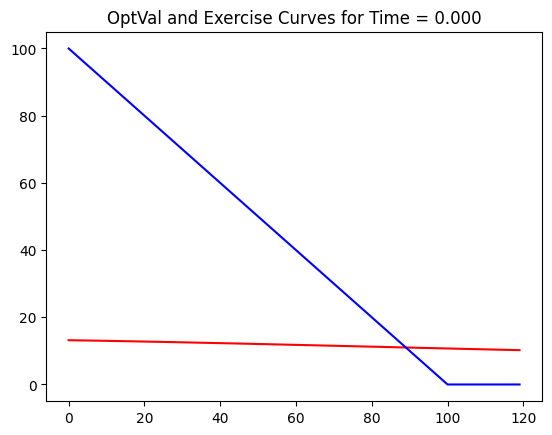

Opt Action = False, Opt Val = 10.714

Time 1

Opt Action = False, Opt Val = 10.770

Time 2

Opt Action = False, Opt Val = 10.845

Time 3

Opt Action = False, Opt Val = 10.825

Time 4

Opt Action = False, Opt Val = 10.691

Time 5



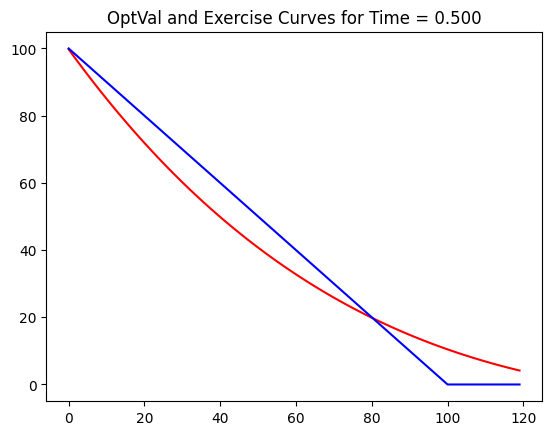

Opt Action = False, Opt Val = 10.447

Time 6

Opt Action = False, Opt Val = 10.037

Time 7

Opt Action = False, Opt Val = 9.485

Time 8

Opt Action = False, Opt Val = 8.747

Time 9



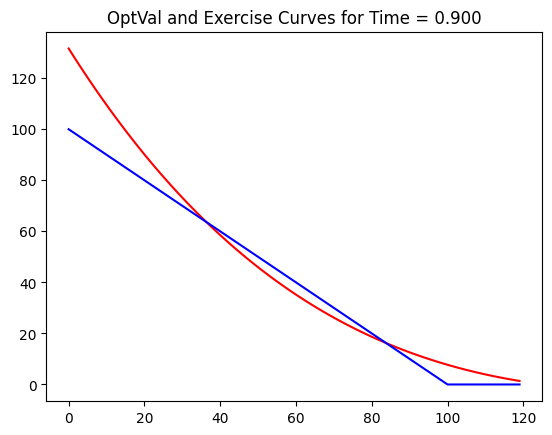

Opt Action = False, Opt Val = 7.713

Time 10

Opt Action = False, Opt Val = 6.172



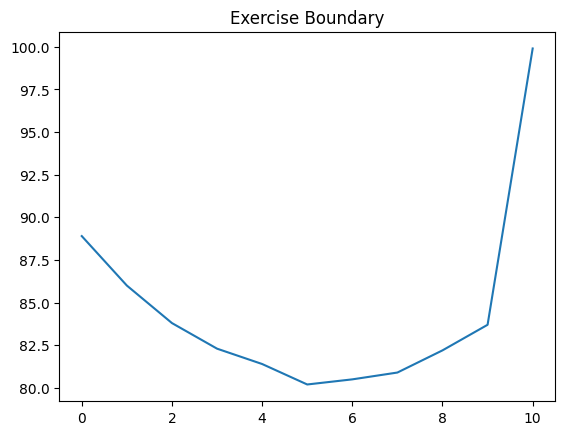

European Put Price
------------------

7.458941380440123


In [ ]:
# 第一步：安装必要的库
!pip install numpy scipy matplotlib

# 第二步：克隆并准备rl库
!git clone https://github.com/TikhonJelvis/RL-book.git
%cd RL-book
!git checkout e3bcaf5fd70fb376d47916def16b308d4e04f70b

# 注意：根据你的Colab环境，可能还需要安装rl库中所需的其他依赖

# 第三步：将rl库的路径添加到Python的模块搜索路径
import sys
sys.path.append('/content/RL-book')

# 第四步：运行你的代码（你已经提供了完整代码，直接粘贴在这里即可）
# 从这里开始粘贴你的代码
from dataclasses import dataclass
from typing import Callable, Sequence, Tuple, Iterator, List
import numpy as np
from scipy.stats import norm
from rl.distribution import SampledDistribution
from rl.markov_decision_process import MarkovDecisionProcess, \
    NonTerminal, State, Terminal
from rl.policy import DeterministicPolicy
from rl.function_approx import FunctionApprox, LinearFunctionApprox
from rl.approximate_dynamic_programming import back_opt_vf_and_policy
from numpy.polynomial.laguerre import lagval


@dataclass(frozen=True)
class OptimalExerciseBI:
    '''Optimal Exercise with Backward Induction when the underlying
    price follows a lognormal process'''

    spot_price: float
    payoff: Callable[[float], float]
    expiry: float
    rate: float
    vol: float
    num_steps: int
    spot_price_frac: float

    def european_put_price(self, strike: float) -> float:
        sigma_sqrt: float = self.vol * np.sqrt(self.expiry)
        d1: float = (np.log(self.spot_price / strike) +
                     (self.rate + self.vol ** 2 / 2.) * self.expiry) \
            / sigma_sqrt
        d2: float = d1 - sigma_sqrt
        return strike * np.exp(-self.rate * self.expiry) * norm.cdf(-d2) \
            - self.spot_price * norm.cdf(-d1)

    def get_mdp(self, t: int) -> MarkovDecisionProcess[float, bool]:
        dt: float = self.expiry / self.num_steps
        exer_payoff: Callable[[float], float] = self.payoff
        r: float = self.rate
        s: float = self.vol

        class OptExerciseBIMDP(MarkovDecisionProcess[float, bool]):

            def step(
                self,
                price: NonTerminal[float],
                exer: bool
            ) -> SampledDistribution[Tuple[State[float], float]]:

                def sr_sampler_func(
                    price=price,
                    exer=exer
                ) -> Tuple[State[float], float]:
                    if exer:
                        return Terminal(0.), exer_payoff(price.state)
                    else:
                        next_price: float = np.exp(np.random.normal(
                            np.log(price.state) + (r - s * s / 2) * dt,
                            s * np.sqrt(dt)
                        ))
                        return NonTerminal(next_price), 0.

                return SampledDistribution(
                    sampler=sr_sampler_func,
                    expectation_samples=200
                )

            def actions(self, price: NonTerminal[float]) -> Sequence[bool]:
                return [True, False]

        return OptExerciseBIMDP()

    def get_states_distribution(
        self,
        t: int
    ) -> SampledDistribution[NonTerminal[float]]:
        spot_mean2: float = self.spot_price * self.spot_price
        spot_var: float = spot_mean2 * \
            self.spot_price_frac * self.spot_price_frac
        log_mean: float = np.log(spot_mean2 / np.sqrt(spot_var + spot_mean2))
        log_stdev: float = np.sqrt(np.log(spot_var / spot_mean2 + 1))

        time: float = t * self.expiry / self.num_steps

        def states_sampler_func() -> NonTerminal[float]:
            start: float = np.random.lognormal(log_mean, log_stdev)
            price = np.exp(np.random.normal(
                np.log(start) + (self.rate - self.vol * self.vol / 2) * time,
                self.vol * np.sqrt(time)
            ))
            return NonTerminal(price)

        return SampledDistribution(states_sampler_func)

    def get_vf_func_approx(
        self,
        t: int,
        features: Sequence[Callable[[NonTerminal[float]], float]],
        reg_coeff: float
    ) -> LinearFunctionApprox[NonTerminal[float]]:
        return LinearFunctionApprox.create(
            feature_functions=features,
            regularization_coeff=reg_coeff,
            direct_solve=True
        )

    def backward_induction_vf_and_pi(
        self,
        features: Sequence[Callable[[NonTerminal[float]], float]],
        reg_coeff: float
    ) -> Iterator[
        Tuple[FunctionApprox[NonTerminal[float]],
              DeterministicPolicy[float, bool]]
    ]:

        mdp_f0_mu_triples: Sequence[Tuple[
            MarkovDecisionProcess[float, bool],
            FunctionApprox[NonTerminal[float]],
            SampledDistribution[NonTerminal[float]]
        ]] = [(
            self.get_mdp(t=i),
            self.get_vf_func_approx(
                t=i,
                features=features,
                reg_coeff=reg_coeff
            ),
            self.get_states_distribution(t=i)
        ) for i in range(self.num_steps + 1)]

        num_state_samples: int = 1000

        return back_opt_vf_and_policy(
            mdp_f0_mu_triples=mdp_f0_mu_triples,
            γ=np.exp(-self.rate * self.expiry / self.num_steps),
            num_state_samples=num_state_samples,
            error_tolerance=1e-8
        )

    def optimal_value_curve(
        self,
        func: FunctionApprox[NonTerminal[float]],
        prices: Sequence[float]
    ) -> np.ndarray:
        return func.evaluate([NonTerminal(p) for p in prices])

    def exercise_curve(
        self,
        prices: Sequence[float]
    ) -> np.ndarray:
        return np.array([self.payoff(p) for p in prices])

    def put_option_exercise_boundary(
        self,
        opt_vfs: Sequence[FunctionApprox[NonTerminal[float]]],
        strike: float
    ) -> Sequence[float]:
        ret: List[float] = []
        prices: np.ndarray = np.arange(0., strike + 0.1, 0.1)
        for vf in opt_vfs[:-1]:
            cp: np.ndarray = self.optimal_value_curve(
                func=vf,
                prices=prices
            )
            ep: np.ndarray = self.exercise_curve(prices=prices)
            ll: Sequence[float] = [p for p, c, e in zip(prices, cp, ep)
                                   if e > c]
            ret.append(max(ll) if len(ll) > 0 else 0.)
        final: Sequence[Tuple[float, float]] = \
            [(p, self.payoff(p)) for p in prices]
        ret.append(max(p for p, e in final if e > 0))
        return ret


if __name__ == '__main__':
    import matplotlib.pyplot as plt

    spot_price_val: float = 100.0
    strike: float = 100.0
    expiry_val: float = 1.0
    rate_val: float = 0.05
    vol_val: float = 0.25
    num_steps_val: int = 10
    spot_price_frac_val: float = 0.02

    opt_ex_bi: OptimalExerciseBI = OptimalExerciseBI(
        spot_price=spot_price_val,
        payoff=lambda x: max(strike - x, 0.),
        expiry=expiry_val,
        rate=rate_val,
        vol=vol_val,
        num_steps=num_steps_val,
        spot_price_frac=spot_price_frac_val
    )

    num_laguerre: int = 4
    reglr_coeff: float = 0.001

    ident: np.ndarray = np.eye(num_laguerre)
    ffs: List[Callable[[NonTerminal[float]], float]] = [lambda _: 1.]
    ffs += [(lambda s, i=i: np.log(1 + np.exp(-s.state / (2 * strike))) *
            lagval(s.state / strike, ident[i]))
            for i in range(num_laguerre)]
    it_vf = opt_ex_bi.backward_induction_vf_and_pi(
        features=ffs,
        reg_coeff=reglr_coeff
    )

    prices: np.ndarray = np.arange(120.0)

    print("Backward Induction: VF And Policy")
    print("---------------------------------")
    print()

    all_funcs: List[FunctionApprox[NonTerminal[float]]] = []
    for t, (v, p) in enumerate(it_vf):
        print(f"Time {t:d}")
        print()

        if t == 0 or t == int(num_steps_val / 2) or t == num_steps_val - 1:
            exer_curve: np.ndarray = opt_ex_bi.exercise_curve(
                prices=prices
            )
            opt_val_curve: np.ndarray = opt_ex_bi.optimal_value_curve(
                func=v,
                prices=prices
            )
            plt.plot(
                prices,
                opt_val_curve,
                "r",
                prices,
                exer_curve,
                "b"
            )
            time: float = t * expiry_val / num_steps_val
            plt.title(f"OptVal and Exercise Curves for Time = {time:.3f}")
            plt.show()

        all_funcs.append(v)

        opt_alloc: float = p.action_for(spot_price_val)
        val: float = v(NonTerminal(spot_price_val))
        print(f"Opt Action = {opt_alloc}, Opt Val = {val:.3f}")
        print()

    ex_bound: Sequence[float] = opt_ex_bi.put_option_exercise_boundary(
        all_funcs,
        strike
    )
    plt.plot(range(num_steps_val + 1), ex_bound)
    plt.title("Exercise Boundary")
    plt.show()

    print("European Put Price")
    print("------------------")
    print()
    print(opt_ex_bi.european_put_price(strike=strike))

# 确保你的代码可以正确执行
#if __name__ == '__main__':
    # 你的主逻辑
